**ECCM vs Improvement scatter with old and new ratios**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

# -----------------------------
# 1. Load old and new merge histories 
# -----------------------------

fraud_old = pd.read_csv("../results/merges/fraud/merge_results_old_eccm.csv")
fraud_new = pd.read_csv("../results/merges/fraud/merge_results_new_eccm.csv")
churn_old = pd.read_csv("../results/merges/churn/merge_results_old_eccm.csv")
churn_new = pd.read_csv("../results/merges/churn/merge_results_new_eccm.csv")

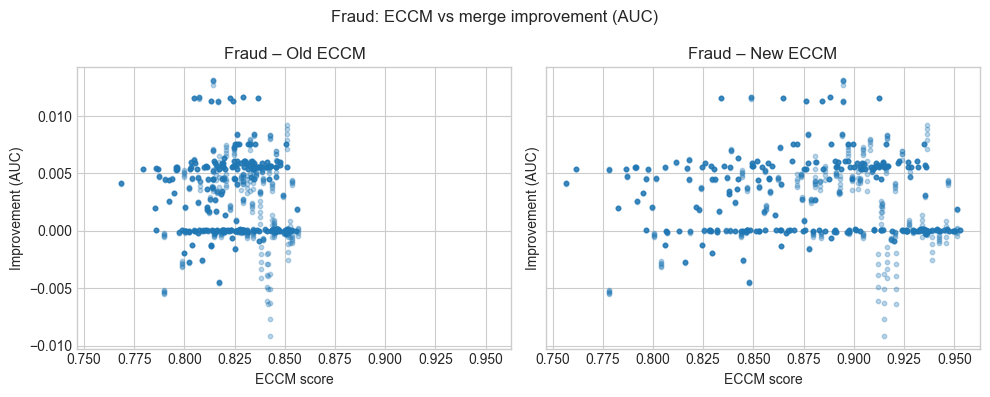

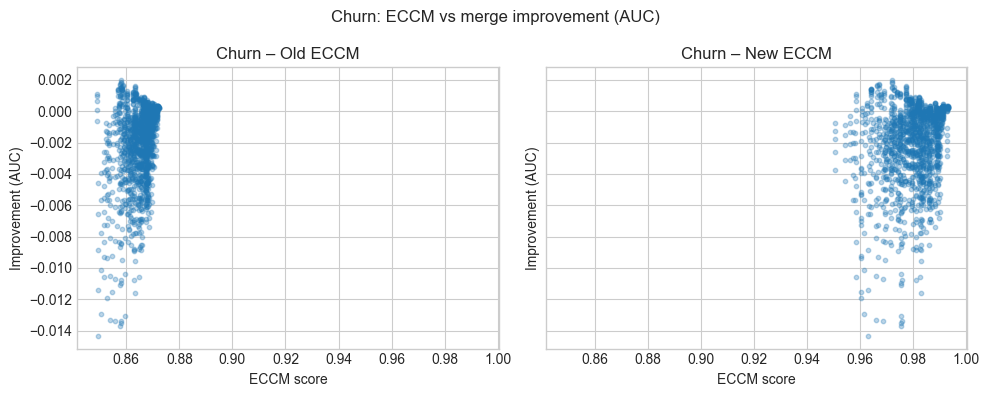

In [3]:
def eccm_scatter(df, title, ax):
    ax.scatter(df["eccm"], df["improvement"], alpha=0.3, s=10)
    ax.set_xlabel("ECCM score")
    ax.set_ylabel("Improvement (AUC)")
    ax.set_title(title)

# ----- Figure 1: Fraud -----
fig_fraud, axes_fraud = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

eccm_scatter(fraud_old, "Fraud – Old ECCM", axes_fraud[0])
eccm_scatter(fraud_new, "Fraud – New ECCM", axes_fraud[1])

fig_fraud.suptitle("Fraud: ECCM vs merge improvement (AUC)")
fig_fraud.tight_layout()
plt.show()

# ----- Figure 2: Churn -----
fig_churn, axes_churn = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

eccm_scatter(churn_old, "Churn – Old ECCM", axes_churn[0])
eccm_scatter(churn_new, "Churn – New ECCM", axes_churn[1])

fig_churn.suptitle("Churn: ECCM vs merge improvement (AUC)")
fig_churn.tight_layout()
plt.show()

In the old ECCM plot, most fraud merges cluster around ECCM - 0.80–0.85 with small positive and negative improvements mixed together.

In the new ECCM plot, ECCM scores are shifted higher (0.85–0.95) and you see more points with positive improvement at the higher ECCM end.

This shows theres a positive relationship between ECCM and merge improvement rather than an equal weight baseline.

With old ECCM, churn scores are squeezed in a very narrow band (0.85–0.87), and almost all improvements are negative or near zero. ECCM hardly distinguishes between “good” and “bad” churn merges.

With new ECCM, ECCM scores spread out more (0.95–1.0) and the cloud of points shows clearer structure: higher ECCM values tend to correspond to less negative or slightly positive improvements.

This goes to show that ECCM helped with the clarity of displaying merges that show a merge improvement with merges that are harmful to the models.